In [29]:
from pathlib import Path
from dataclasses import dataclass
from typing import List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PROJECT PATHS
# ============================================================

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists() or (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Project root not found. Run the notebook from inside the project repository.")


ROOT = find_project_root()
RAW_ROOT = ROOT / "data" / "raw"
OUTPUT_DIR = ROOT / "reports" / "9_humidty"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW_ROOT:", RAW_ROOT)


# ============================================================
# SETTINGS
# ============================================================

CONDITIONS = ["no_wind", "wind_low", "wind_high"]

RH_SIGNALS = [
    "RH DORSAL",
    "RH MICROCLIMATEBACK",
    "RH MICROCLIMATEFRONT",
    "RH ENVIRONMENT",
]

WINDOW_MINUTES = 60
START_TIMES_PATH = RAW_ROOT / "session_start_times.csv"


# ============================================================
# READERS, presi dalla tua pipeline
# ============================================================

@dataclass
class SessionInfo:
    subject_id: str
    condition: str
    start_time: pd.Timestamp


def normalize_text(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def parse_datetime_series(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()

    s = s.str.replace(
        r"(\d{1,2})\.(\d{2})\.(\d{2})$",
        r"\1:\2:\3",
        regex=True
    )

    formats = [
        "%d/%m/%y %H:%M:%S",
        "%d/%m/%Y %H:%M:%S",
        "%d/%m/%y %H:%M",
        "%d/%m/%Y %H:%M",
    ]

    best = None
    best_count = -1

    for fmt in formats:
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        count = parsed.notna().sum()
        if count > best_count:
            best = parsed
            best_count = count

    if best is not None and best_count > 0:
        return best

    return pd.to_datetime(s, errors="coerce", dayfirst=True)


def load_start_times(path: Path) -> List[SessionInfo]:
    df = pd.read_csv(path, dtype=str)

    df["subject_id"] = df["subject_id"].astype(str).str.strip()
    df["condition"] = df["condition"].astype(str).str.strip()
    df["start_time"] = parse_datetime_series(df["start_time"])

    return [
        SessionInfo(row.subject_id, row.condition, row.start_time)
        for row in df.itertuples(index=False)
    ]


def find_rh_file(session_dir: Path, signal_name: str) -> Path:
    folder = session_dir / "RH"

    if not folder.exists():
        raise FileNotFoundError(f"Missing RH folder: {folder}")

    expected = folder / f"{signal_name}.csv"
    if expected.exists():
        return expected

    normalized_expected = normalize_text(signal_name)
    candidates = list(folder.glob("*.csv"))

    for path in candidates:
        if normalize_text(path.stem) == normalized_expected:
            return path

    raise FileNotFoundError(
        f"File {signal_name}.csv not found in {folder}. "
        f"Available: {[p.name for p in candidates]}"
    )


def read_temperature_humidity_csv(path: Path) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_row = None
    for i, line in enumerate(lines):
        if "Date/Time" in line:
            header_row = i
            break

    if header_row is None:
        raise ValueError(f'Could not find "Date/Time" header in {path}')

    data = pd.read_csv(
        path,
        skiprows=header_row,
        dtype=str,
        engine="python",
        sep=None,
    )

    data = data.reset_index()

    data = data.iloc[:, :4].copy()
    data.columns = ["timestamp", "unit", "value_int", "value_dec"]

    data["timestamp"] = data["timestamp"].astype(str).str.strip()
    data["value_int"] = data["value_int"].astype(str).str.strip()
    data["value_dec"] = data["value_dec"].astype(str).str.strip()

    data["value"] = data["value_int"] + "." + data["value_dec"]

    data["timestamp"] = parse_datetime_series(data["timestamp"])
    data["value"] = pd.to_numeric(data["value"], errors="coerce")

    data = data.dropna(subset=["timestamp", "value"])
    data = data.sort_values("timestamp").reset_index(drop=True)

    return data[["timestamp", "value"]]


def slice_session_window(df, start_time, duration_minutes):
    end_time = start_time + pd.Timedelta(minutes=duration_minutes)

    window = df.loc[
        (df["timestamp"] >= start_time) &
        (df["timestamp"] < end_time)
    ].copy()

    if window.empty:
        return window

    window["elapsed_seconds"] = (window["timestamp"] - start_time).dt.total_seconds()
    window["elapsed_minutes"] = window["elapsed_seconds"] / 60

    return window


# ============================================================
# BUILD RH LONG DATASET
# ============================================================

session_infos = load_start_times(START_TIMES_PATH)

all_rh = []

for session in session_infos:
    session_dir = RAW_ROOT / session.subject_id / session.condition

    for signal_name in RH_SIGNALS:
        try:
            file_path = find_rh_file(session_dir, signal_name)
            raw = read_temperature_humidity_csv(file_path)
            window = slice_session_window(raw, session.start_time, WINDOW_MINUTES)

            if window.empty:
                print(f"Empty window: {session.subject_id} | {session.condition} | {signal_name}")
                continue

            window["subject_id"] = session.subject_id
            window["condition"] = session.condition
            window["signal"] = signal_name.lower().replace(" ", "_")

            all_rh.append(window)

        except Exception as e:
            print(f"WARNING: {session.subject_id} | {session.condition} | {signal_name}: {e}")

if len(all_rh) == 0:
    raise RuntimeError("Nessun dato RH letto. Controlla ROOT, session_start_times.csv e nomi dei file.")

rh_long = pd.concat(all_rh, ignore_index=True)

rh_long.to_csv(OUTPUT_DIR / "rh_long.csv", index=False)

print("RH data loaded:")
print(rh_long.groupby(["subject_id", "condition", "signal"]).size())

ROOT: /home/eleonorab/repository/convective_cooling
RAW_ROOT: /home/eleonorab/repository/convective_cooling/data/raw


Empty window: tester_08 | wind_high | RH DORSAL
Empty window: tester_08 | wind_high | RH MICROCLIMATEBACK
Empty window: tester_08 | wind_high | RH MICROCLIMATEFRONT
Empty window: tester_08 | wind_high | RH ENVIRONMENT
RH data loaded:
subject_id  condition  signal              
tester_01   no_wind    rh_dorsal               360
                       rh_environment          360
                       rh_microclimateback     360
                       rh_microclimatefront    360
            wind_high  rh_dorsal               360
                                              ... 
tester_10   no_wind    rh_microclimatefront    360
            wind_low   rh_dorsal               360
                       rh_environment          360
                       rh_microclimateback     360
                       rh_microclimatefront    360
Length: 111, dtype: int64


In [30]:
rh_wide = rh_long.pivot_table(
    index=[
        "subject_id",
        "condition",
        "timestamp",
        "elapsed_seconds",
        "elapsed_minutes",
    ],
    columns="signal",
    values="value"
).reset_index()

rh_wide.columns.name = None

rh_wide.to_csv(OUTPUT_DIR / "rh_wide.csv", index=False)

print(rh_wide.head())
print(rh_wide.columns)

# ============================================================
# RH DYNAMIC METRICS
# ============================================================

def compute_dynamic_metrics(g: pd.DataFrame, signal: str) -> dict:
    g = g.sort_values("elapsed_seconds").dropna(subset=[signal])

    t = g["elapsed_seconds"].to_numpy()
    y = g[signal].to_numpy()

    if len(y) < 5:
        return {
            f"{signal}_initial": np.nan,
            f"{signal}_final": np.nan,
            f"{signal}_delta": np.nan,
            f"{signal}_range": np.nan,
            f"{signal}_mean_abs_slope": np.nan,
            f"{signal}_auc_from_initial": np.nan,
            f"{signal}_tau63_s": np.nan,
        }

    n_edge = max(3, len(y) // 20)

    y_initial = np.nanmean(y[:n_edge])
    y_final = np.nanmean(y[-n_edge:])
    y_delta = y_final - y_initial
    y_range = np.nanmax(y) - np.nanmin(y)

    dy_dt = np.gradient(y, t)
    mean_abs_slope = np.nanmean(np.abs(dy_dt))

    duration = t[-1] - t[0]
    auc_from_initial = np.trapz(np.abs(y - y_initial), t) / duration

    target = y_initial + 0.632 * y_delta

    if y_delta >= 0:
        idx = np.where(y >= target)[0]
    else:
        idx = np.where(y <= target)[0]

    tau63 = t[idx[0]] - t[0] if len(idx) > 0 else np.nan

    return {
        f"{signal}_initial": y_initial,
        f"{signal}_final": y_final,
        f"{signal}_delta": y_delta,
        f"{signal}_range": y_range,
        f"{signal}_mean_abs_slope": mean_abs_slope,
        f"{signal}_auc_from_initial": auc_from_initial,
        f"{signal}_tau63_s": tau63,
    }


signals_for_metrics = [
    "rh_dorsal",
    "rh_microclimateback",
    "rh_microclimatefront",
    "rh_environment",
]

rows = []

for (subject_id, condition), g in rh_wide.groupby(["subject_id", "condition"]):
    row = {
        "subject_id": subject_id,
        "condition": condition,
    }

    for signal in signals_for_metrics:
        if signal in g.columns:
            row.update(compute_dynamic_metrics(g, signal))

    if "rh_dorsal" in g.columns and "rh_microclimateback" in g.columns:
        g = g.copy()
        g["rh_skin_microclimate_gradient"] = g["rh_dorsal"] - g["rh_microclimateback"]
        row.update(compute_dynamic_metrics(g, "rh_skin_microclimate_gradient"))

    if "rh_microclimateback" in g.columns and "rh_environment" in g.columns:
        g = g.copy()
        g["rh_microclimate_environment_gradient"] = (
            g["rh_microclimateback"] - g["rh_environment"]
        )
        row.update(compute_dynamic_metrics(g, "rh_microclimate_environment_gradient"))

    rows.append(row)

rh_metrics = pd.DataFrame(rows)
rh_metrics.to_csv(OUTPUT_DIR / "rh_dynamic_metrics_by_subject_condition.csv", index=False)

print(rh_metrics.head())

  subject_id condition           timestamp  elapsed_seconds  elapsed_minutes  \
0  tester_01   no_wind 2026-04-23 10:02:04              4.0         0.066667   
1  tester_01   no_wind 2026-04-23 10:02:06              6.0         0.100000   
2  tester_01   no_wind 2026-04-23 10:02:07              7.0         0.116667   
3  tester_01   no_wind 2026-04-23 10:02:14             14.0         0.233333   
4  tester_01   no_wind 2026-04-23 10:02:16             16.0         0.266667   

   rh_dorsal  rh_environment  rh_microclimateback  rh_microclimatefront  
0     64.463             NaN               65.717                   NaN  
1        NaN          61.162                  NaN                   NaN  
2        NaN             NaN                  NaN                55.461  
3     64.749             NaN               65.575                   NaN  
4        NaN          61.162                  NaN                   NaN  
Index(['subject_id', 'condition', 'timestamp', 'elapsed_seconds',
       'e

/tmp/ipykernel_299441/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


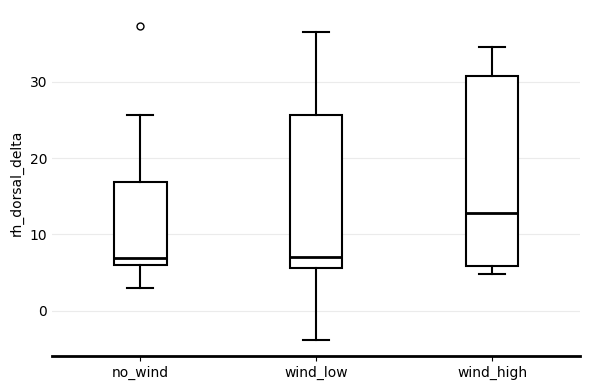

/tmp/ipykernel_299441/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


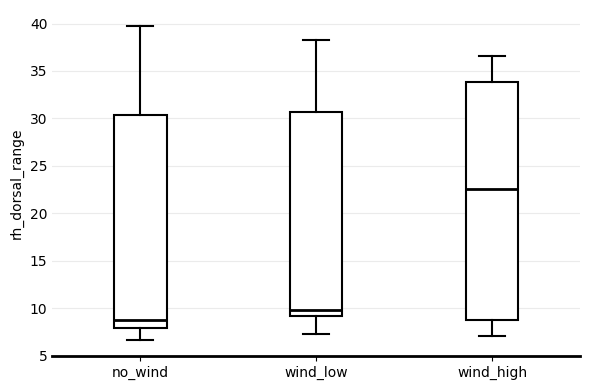

/tmp/ipykernel_299441/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


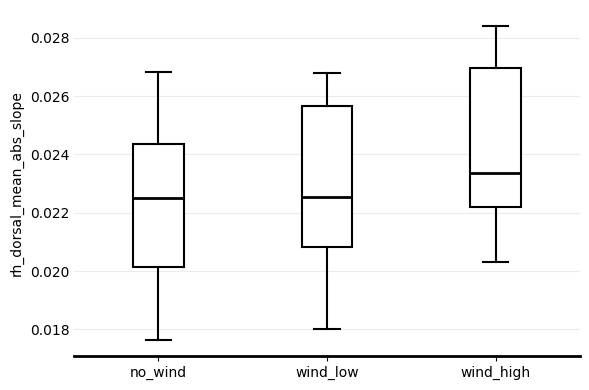

/tmp/ipykernel_299441/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


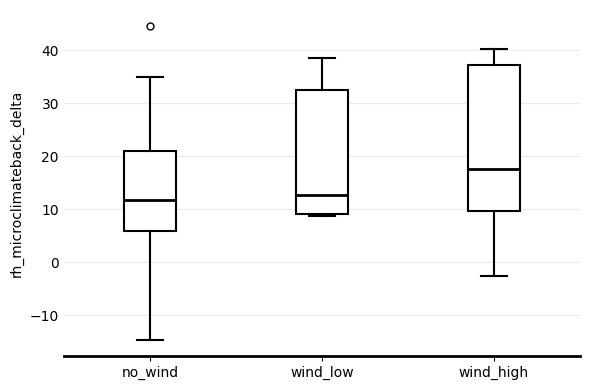

/tmp/ipykernel_299441/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


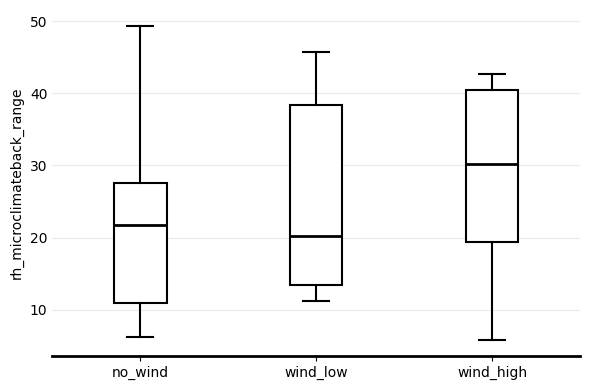

/tmp/ipykernel_299441/3964112886.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


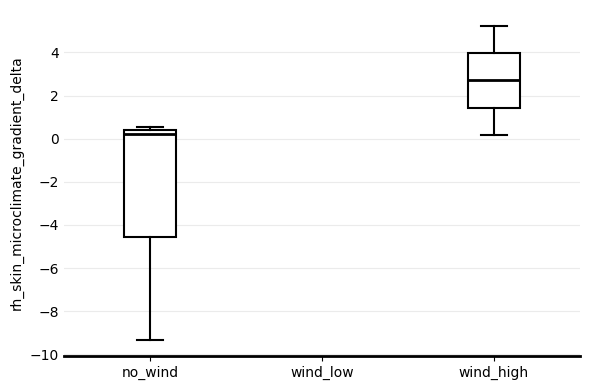

In [31]:
# ============================================================
# PLOT RH DYNAMICS BY CONDITION
# ============================================================

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", alpha=0.25)


for metric in [
    "rh_dorsal_delta",
    "rh_dorsal_range",
    "rh_dorsal_mean_abs_slope",
    "rh_microclimateback_delta",
    "rh_microclimateback_range",
    "rh_skin_microclimate_gradient_delta",
]:
    if metric not in rh_metrics.columns:
        continue

    fig, ax = plt.subplots(figsize=(6, 4))

    data = [
        rh_metrics.loc[rh_metrics["condition"] == cond, metric].dropna()
        for cond in CONDITIONS
    ]

    ax.boxplot(
        data,
        labels=CONDITIONS,
        patch_artist=True,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.5),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=5,
        ),
    )

    ax.set_ylabel(metric)
    clean_axes(ax)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{metric}_by_condition.png", dpi=300)
    plt.show()

ROOT: /home/eleonorab/repository/convective_cooling
FEATURES_DIR: /home/eleonorab/repository/convective_cooling/data/processed/features
AGG_DIR: /home/eleonorab/repository/convective_cooling/data/processed/aggregated_by_signal

Thermal dynamic dataset
(7189, 12)
['subject_id', 'condition', 'elapsed_seconds_bin', 'elapsed_minutes_bin', 't_dorsal', 't_microclimateback', 'phase', 'delta_t_loc', 't_dorsal_smooth', 'dt_dorsal_dt', 'minus_dt_dorsal_dt', 'hti_app']

Transition k summary
(18, 10)
['phase', 'condition', 'n', 'mean_k', 'median_k', 'sd_k', 'mean_tau', 'median_tau', 'mean_r2', 'median_r2']

RH dorsal
(8280, 8)
['subject_id', 'condition', 'signal_group', 'signal_name', 'timestamp', 'elapsed_seconds', 'elapsed_minutes', 'value']

RH microclimate back
(8277, 8)
['subject_id', 'condition', 'signal_group', 'signal_name', 'timestamp', 'elapsed_seconds', 'elapsed_minutes', 'value']

RH environment
(7920, 8)
['subject_id', 'condition', 'signal_group', 'signal_name', 'timestamp', 'elapsed_

,subject_id,condition,elapsed_seconds_bin,elapsed_minutes_bin,rh_dorsal,rh_microclimateback,rh_environment
0,tester_01,no_wind,0.0,0.0,64.606000,65.646000,61.162
1,tester_01,no_wind,30.0,0.5,65.316333,62.026667,61.006
2,tester_01,no_wind,60.0,1.0,66.258667,58.489333,60.590
3,tester_01,no_wind,90.0,1.5,67.706000,57.702000,60.642
4,tester_01,no_wind,120.0,2.0,68.586667,57.456000,60.174



Thermal + RH dataset
(7189, 15)


,subject_id,condition,elapsed_seconds_bin,elapsed_minutes_bin,t_dorsal,t_microclimateback,phase,delta_t_loc,t_dorsal_smooth,dt_dorsal_dt,minus_dt_dorsal_dt,hti_app,rh_dorsal,rh_microclimateback,rh_environment
0,tester_01,no_wind,0.0,0.000000,34.683,35.637,standing_1,-0.954,34.701336,0.001983,-0.001983,480.968834,64.606000,65.646000,61.162
1,tester_01,no_wind,10.0,0.166667,34.746,35.699,standing_1,-0.953,34.721171,0.002028,-0.002028,470.024833,NaN,NaN,NaN
2,tester_01,no_wind,20.0,0.333333,34.746,35.699,standing_1,-0.953,34.741887,0.002116,-0.002116,450.449527,NaN,NaN,NaN
3,tester_01,no_wind,30.0,0.500000,34.746,35.699,standing_1,-0.953,34.763484,0.002204,-0.002204,432.439551,65.316333,62.026667,61.006
4,tester_01,no_wind,40.0,0.666667,34.808,35.699,standing_1,-0.891,34.785962,0.002292,-0.002292,388.762434,NaN,NaN,NaN



RH metrics by subject
(132, 25)


...


RH metrics summary
(18, 24)


,phase,condition,rh_dorsal_mean,rh_dorsal_delta,rh_dorsal_range,rh_microclimateback_mean,rh_microclimateback_delta,rh_microclimateback_range,rh_environment_mean,rh_environment_delta,...,rh_microclimate_environment_diff_mean,rh_microclimate_environment_diff_delta,rh_microclimate_environment_diff_range,rh_dorsal_slope_mean_abs,rh_microclimateback_slope_mean_abs,rh_environment_slope_mean_abs,rh_skin_microclimate_diff_slope_mean_abs,rh_microclimate_environment_diff_slope_mean_abs,rh_transient_intensity_slope_mean_abs,rh_decoupling_intensity_slope_mean_abs
0,standing_1,no_wind,81.850797,9.951854,10.651490,77.407704,4.070208,9.387646,60.833011,-0.883688,...,16.574693,4.953896,10.202438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,standing_1,wind_high,79.363604,9.734095,10.047095,75.269749,9.408333,11.679238,58.970130,-0.699000,...,16.299619,10.107333,12.287190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,standing_1,wind_low,81.439017,8.399107,8.694774,76.472286,6.074786,9.314000,60.648750,-0.939722,...,14.591545,8.393083,11.128931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,standing_2,no_wind,92.529394,0.134188,1.469417,92.084854,-2.702604,4.053458,70.342500,1.672583,...,21.742354,-4.375188,4.924208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,standing_2,wind_high,93.356135,0.574548,1.355476,92.894287,1.047310,3.243857,70.790476,1.889095,...,22.103810,-0.841786,3.622857,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Merged model summary + RH summary
(18, 33)


,phase,condition,n,mean_k,median_k,sd_k,mean_tau,median_tau,mean_r2,median_r2,...,rh_microclimate_environment_diff_mean,rh_microclimate_environment_diff_delta,rh_microclimate_environment_diff_range,rh_dorsal_slope_mean_abs,rh_microclimateback_slope_mean_abs,rh_environment_slope_mean_abs,rh_skin_microclimate_diff_slope_mean_abs,rh_microclimate_environment_diff_slope_mean_abs,rh_transient_intensity_slope_mean_abs,rh_decoupling_intensity_slope_mean_abs
0,standing_1,no_wind,8,0.005868,0.004232,0.006586,1253.510049,248.051244,0.963436,0.982493,...,16.574693,4.953896,10.202438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,standing_1,wind_low,7,0.009355,0.008013,0.006311,197.870978,124.794005,0.954016,0.962107,...,14.591545,8.393083,11.128931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,standing_1,wind_high,7,0.006130,0.006870,0.004397,1705.005838,145.559963,0.962723,0.987227,...,16.299619,10.107333,12.287190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,walk_low_1,no_wind,8,0.004844,0.000090,0.013463,15385.667632,11234.613253,0.799968,0.840099,...,21.461256,4.531833,5.187042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,walk_low_1,wind_low,7,0.003546,0.000555,0.004267,1598.163940,1800.307134,0.934816,0.933567,...,18.075614,1.743986,6.472653,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,variable,n,spearman_rho_with_mean_R2,p_with_mean_R2,spearman_rho_with_model_error,p_with_model_error
12,rh_microclimate_environment_diff_mean,18,-0.758514,0.000264,0.758514,0.000264
8,rh_environment_range,18,-0.746130,0.000377,0.746130,0.000377
7,rh_environment_delta,18,-0.735810,0.000500,0.735810,0.000500
3,rh_microclimateback_mean,18,-0.543860,0.019644,0.543860,0.019644
6,rh_environment_mean,18,-0.455108,0.057729,0.455108,0.057729
0,rh_dorsal_mean,18,-0.453044,0.059017,0.453044,0.059017
4,rh_microclimateback_delta,18,0.058824,0.816654,-0.058824,0.816654
13,rh_microclimate_environment_diff_delta,18,0.143447,0.570135,-0.143447,0.570135
1,rh_dorsal_delta,18,0.335397,0.173635,-0.335397,0.173635
2,rh_dorsal_range,18,0.424149,0.079389,-0.424149,0.079389


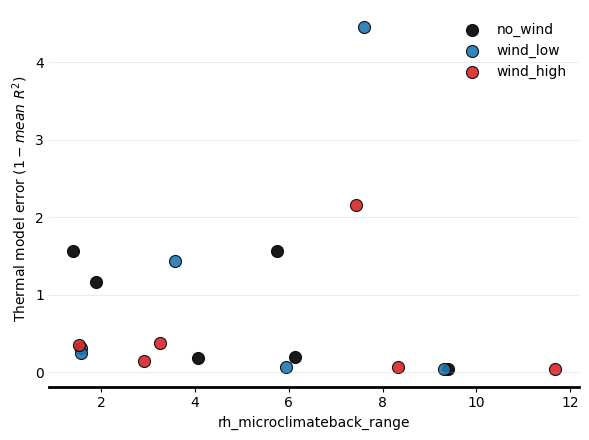

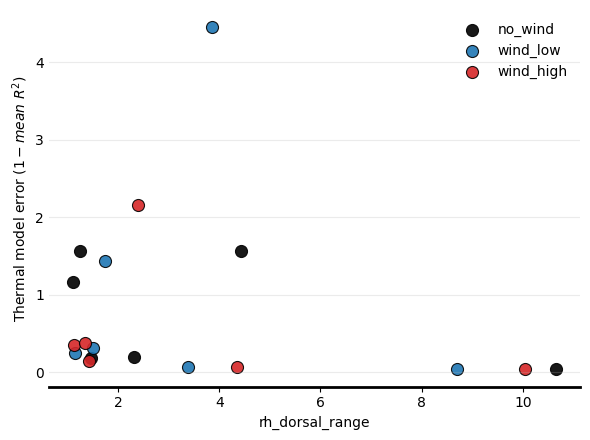

/tmp/ipykernel_299441/2976041575.py:413: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


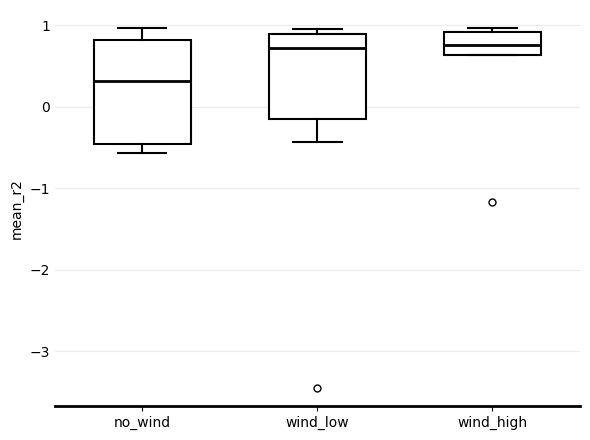

/tmp/ipykernel_299441/2976041575.py:413: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


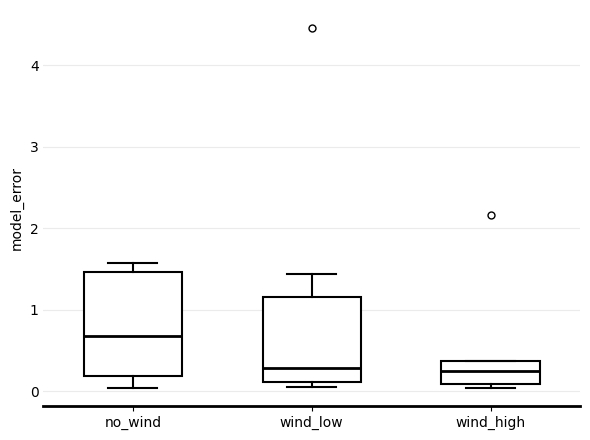

In [32]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ============================================================
# PATHS
# ============================================================

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / ".git").exists():
            return candidate

    raise RuntimeError("Project root not found.")


ROOT = find_project_root()

PROCESSED_DIR = ROOT / "data" / "processed"
FEATURES_DIR = PROCESSED_DIR / "features"
AGG_DIR = PROCESSED_DIR / "aggregated_by_signal"

REPORTS_DIR = ROOT / "reports" / "RH_model_failure"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("FEATURES_DIR:", FEATURES_DIR)
print("AGG_DIR:", AGG_DIR)


# ============================================================
# LOAD THERMAL DYNAMIC DATASET AND MODEL RESULTS
# ============================================================

df = pd.read_csv(FEATURES_DIR / "analysis_dataset_dynamic.csv")
k = pd.read_csv(FEATURES_DIR / "transition_k_summary.csv")

print("\nThermal dynamic dataset")
print(df.shape)
print(df.columns.tolist())

print("\nTransition k summary")
print(k.shape)
print(k.columns.tolist())


# ============================================================
# LOAD RH SIGNALS
# ============================================================

rh_dorsal = pd.read_csv(AGG_DIR / "rh_dorsal.csv")
rh_micro = pd.read_csv(AGG_DIR / "rh_microclimateback.csv")
rh_env = pd.read_csv(AGG_DIR / "rh_environment.csv")

print("\nRH dorsal")
print(rh_dorsal.shape)
print(rh_dorsal.columns.tolist())

print("\nRH microclimate back")
print(rh_micro.shape)
print(rh_micro.columns.tolist())

print("\nRH environment")
print(rh_env.shape)
print(rh_env.columns.tolist())


# ============================================================
# BUILD RH WIDE DATASET
# ============================================================

def bin_rh_signal(data, new_name, bin_seconds=30):
    data = data.copy()

    data["elapsed_seconds_bin"] = (
        data["elapsed_seconds"] / bin_seconds
    ).round() * bin_seconds

    data["elapsed_minutes_bin"] = data["elapsed_seconds_bin"] / 60

    out = (
        data
        .groupby(
            ["subject_id", "condition", "elapsed_seconds_bin", "elapsed_minutes_bin"],
            as_index=False
        )["value"]
        .mean()
        .rename(columns={"value": new_name})
    )

    return out


rh = bin_rh_signal(rh_dorsal, "rh_dorsal")

rh = rh.merge(
    bin_rh_signal(rh_micro, "rh_microclimateback"),
    on=["subject_id", "condition", "elapsed_seconds_bin", "elapsed_minutes_bin"],
    how="outer",
)

rh = rh.merge(
    bin_rh_signal(rh_env, "rh_environment"),
    on=["subject_id", "condition", "elapsed_seconds_bin", "elapsed_minutes_bin"],
    how="outer",
)

print("\nRH wide")
print(rh.shape)
display(rh.head())


# ============================================================
# MERGE THERMAL DATASET WITH RH
# ============================================================

keys = [
    "subject_id",
    "condition",
    "elapsed_seconds_bin",
    "elapsed_minutes_bin",
]

df_rh = df.merge(
    rh,
    on=keys,
    how="left",
)

print("\nThermal + RH dataset")
print(df_rh.shape)
display(df_rh.head())

df_rh.to_csv(REPORTS_DIR / "thermal_dataset_with_RH.csv", index=False)


# ============================================================
# COMPUTE RH LOCAL DESCRIPTORS
# ============================================================

df_rh = df_rh.sort_values(
    ["subject_id", "condition", "phase", "elapsed_seconds_bin"]
).copy()

df_rh["rh_skin_microclimate_diff"] = (
    df_rh["rh_dorsal"] - df_rh["rh_microclimateback"]
)

df_rh["rh_microclimate_environment_diff"] = (
    df_rh["rh_microclimateback"] - df_rh["rh_environment"]
)

group_cols_subject = ["subject_id", "condition", "phase"]

for col in [
    "rh_dorsal",
    "rh_microclimateback",
    "rh_environment",
    "rh_skin_microclimate_diff",
    "rh_microclimate_environment_diff",
]:
    df_rh[f"{col}_slope"] = (
        df_rh.groupby(group_cols_subject)[col].diff()
        /
        df_rh.groupby(group_cols_subject)["elapsed_seconds_bin"].diff()
    )

df_rh["rh_transient_intensity_slope"] = (
    df_rh["rh_dorsal_slope"].abs()
    + df_rh["rh_microclimateback_slope"].abs()
)

df_rh["rh_decoupling_intensity_slope"] = (
    df_rh["rh_skin_microclimate_diff_slope"].abs()
)


# ============================================================
# SUMMARIZE RH METRICS BY SUBJECT, CONDITION, PHASE
# ============================================================

def summarize_group(g):
    out = {}

    for col in [
        "rh_dorsal",
        "rh_microclimateback",
        "rh_environment",
        "rh_skin_microclimate_diff",
        "rh_microclimate_environment_diff",
    ]:
        y = g[col].dropna()

        if len(y) < 3:
            out[f"{col}_mean"] = np.nan
            out[f"{col}_delta"] = np.nan
            out[f"{col}_range"] = np.nan
        else:
            out[f"{col}_mean"] = y.mean()
            out[f"{col}_delta"] = y.iloc[-1] - y.iloc[0]
            out[f"{col}_range"] = y.max() - y.min()

    for col in [
        "rh_dorsal_slope",
        "rh_microclimateback_slope",
        "rh_environment_slope",
        "rh_skin_microclimate_diff_slope",
        "rh_microclimate_environment_diff_slope",
        "rh_transient_intensity_slope",
        "rh_decoupling_intensity_slope",
    ]:
        y = g[col].dropna()

        if len(y) < 3:
            out[f"{col}_mean_abs"] = np.nan
        else:
            out[f"{col}_mean_abs"] = y.abs().mean()

    return pd.Series(out)


rh_metrics_subject = (
    df_rh
    .groupby(group_cols_subject)
    .apply(summarize_group)
    .reset_index()
)

rh_metrics_subject.to_csv(
    REPORTS_DIR / "RH_dynamic_metrics_by_subject_condition_phase.csv",
    index=False,
)

print("\nRH metrics by subject")
print(rh_metrics_subject.shape)
display(rh_metrics_subject.head())


# ============================================================
# AGGREGATE RH METRICS LIKE transition_k_summary.csv
# condition + phase
# ============================================================

metric_cols = [
    c for c in rh_metrics_subject.columns
    if c not in ["subject_id", "condition", "phase"]
]

rh_metrics_summary = (
    rh_metrics_subject
    .groupby(["phase", "condition"], as_index=False)[metric_cols]
    .mean()
)

rh_metrics_summary.to_csv(
    REPORTS_DIR / "RH_dynamic_metrics_summary_by_condition_phase.csv",
    index=False,
)

print("\nRH metrics summary")
print(rh_metrics_summary.shape)
display(rh_metrics_summary.head())


# ============================================================
# MERGE MODEL SUMMARY WITH RH SUMMARY
# ============================================================

model = k.copy()

if "mean_r2" not in model.columns:
    raise ValueError(
        f"transition_k_summary.csv non contiene mean_r2. "
        f"Colonne disponibili: {model.columns.tolist()}"
    )

model["model_error"] = 1 - model["mean_r2"]

merged = model.merge(
    rh_metrics_summary,
    on=["phase", "condition"],
    how="left",
)

merged.to_csv(REPORTS_DIR / "thermal_model_RH_merged_summary.csv", index=False)

print("\nMerged model summary + RH summary")
print(merged.shape)
display(merged.head())


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

from scipy.stats import spearmanr

rh_predictors = [
    col for col in merged.columns
    if col.startswith("rh_")
]

rows = []

for var in rh_predictors:
    tmp = merged[["mean_r2", "model_error", var]].dropna()

    if len(tmp) < 5:
        continue

    rho_r2, p_r2 = spearmanr(tmp[var], tmp["mean_r2"])
    rho_err, p_err = spearmanr(tmp[var], tmp["model_error"])

    rows.append({
        "variable": var,
        "n": len(tmp),
        "spearman_rho_with_mean_R2": rho_r2,
        "p_with_mean_R2": p_r2,
        "spearman_rho_with_model_error": rho_err,
        "p_with_model_error": p_err,
    })

corr = pd.DataFrame(rows)

if len(corr) > 0:
    corr = corr.sort_values("spearman_rho_with_model_error", ascending=False)
    corr.to_csv(REPORTS_DIR / "RH_vs_model_error_spearman_summary.csv", index=False)
    display(corr)
else:
    print("Nessuna correlazione calcolabile.")


# ============================================================
# PLOTS
# ============================================================

CONDITIONS = ["no_wind", "wind_low", "wind_high"]

CONDITION_COLORS = {
    "no_wind": "black",
    "wind_low": "tab:blue",
    "wind_high": "tab:red",
}


def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", alpha=0.25)


def scatter_failure_metric(data, x, y="model_error"):
    fig, ax = plt.subplots(figsize=(6, 4.5))

    for condition in CONDITIONS:
        g = data.loc[data["condition"] == condition]

        ax.scatter(
            g[x],
            g[y],
            label=condition,
            color=CONDITION_COLORS.get(condition, None),
            edgecolor="black",
            linewidth=0.8,
            s=75,
            alpha=0.9,
        )

    ax.set_xlabel(x)
    ax.set_ylabel(r"Thermal model error $(1 - mean\ R^2)$")
    ax.legend(frameon=False)
    clean_axes(ax)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"summary_model_error_vs_{x}.png", dpi=300)
    plt.show()


main_predictors = [
    "rh_microclimateback_range",
    "rh_dorsal_range",
]

for x in main_predictors:
    if x in merged.columns:
        scatter_failure_metric(merged, x=x)


metrics_to_plot = [
    "mean_r2",
    "model_error",
]

for metric in metrics_to_plot:
    if metric not in merged.columns:
        continue

    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [
        merged.loc[merged["condition"] == cond, metric].dropna()
        for cond in CONDITIONS
    ]

    ax.boxplot(
        data,
        labels=CONDITIONS,
        patch_artist=True,
        widths=0.55,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.5),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black", linewidth=1.5),
        capprops=dict(color="black", linewidth=1.5),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=5,
        ),
    )

    ax.set_ylabel(metric)
    clean_axes(ax)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"summary_{metric}_by_condition.png", dpi=300)
    plt.show()